In [15]:
# Importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 10
plt.style.use('default')

# 📊 Guía Completa: Manipulación y Visualización de Datos

**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**  
Facultad de Ciencias Económicas - Universidad de Buenos Aires

---

## 📚 Contenidos

### 🔹 Análisis Avanzado con Pandas
1. [Operaciones de Agrupación (groupby)](#groupby)
2. [Pivoteo y Reshape de Datos](#pivoteo)
3. [Merge y Join de DataFrames](#merge)
4. [Series Temporales](#series-temporales)

### 🔹 Visualización de Datos
5. [Matplotlib Avanzado](#matplotlib-avanzado)
6. [Seaborn para Análisis Estadístico](#seaborn)
7. [Dashboards Básicos](#dashboards)
8. [Gráficos Económicos Especializados](#graficos-economicos)

### 🔹 Análisis Estadístico Descriptivo
9. [Medidas de Tendencia Central](#tendencia-central)
10. [Dispersión y Variabilidad](#dispersion)
11. [Distribuciones](#distribuciones)
12. [Correlaciones](#correlaciones)

### 🔹 Aplicación
13. [Workflow de Análisis de Datos](#workflow)
14. [Caso Práctico Completo](#caso-practico)
15. [Tabla de Funciones](#funciones)

---

---

<a id="groupby"></a>

## 1️⃣ Operaciones de Agrupación (groupby)

### 📌 Conceptos Fundamentales

El método `groupby` es una de las herramientas más poderosas de pandas para análisis de datos empresariales. Permite dividir datos en grupos, aplicar funciones y combinar resultados.

### 📐 Estructura Básica

```python
# Patrón básico
df.groupby('columna_agrupacion')['columna_analizar'].operacion()

# Múltiples columnas
df.groupby(['col1', 'col2']).operacion()

# Con filtros previos
df[df['condicion']].groupby('columna').operacion()
```

### 🏢 Casos de Uso Empresariales

| Operación | Uso Empresarial | Ejemplo |
|-----------|----------------|---------|
| **sum()** | Totales por categoría | Ventas por región |
| **mean()** | Promedios | Precio promedio por producto |
| **count()** | Frecuencias | Número de transacciones por cliente |
| **std()** | Variabilidad | Volatilidad de precios por sector |
| **agg()** | Múltiples métricas | Min, max, promedio en una sola operación |

### 🔍 Operaciones Principales

#### **1. Agrupación Simple**

```python
# Ejemplo: Análisis de ventas por región
ventas_por_region = df.groupby('region')['ventas'].sum()
```

#### **2. Agrupación Múltiple**

```python
# Ejemplo: Ventas por región y trimestre
analisis_completo = df.groupby(['region', 'trimestre'])['ventas'].agg(['sum', 'mean', 'count'])
```

#### **3. Filtrado Después de Agrupación**

```python
# Ejemplo: Solo regiones con ventas > 100,000
regiones_importantes = df.groupby('region')['ventas'].sum()
regiones_altas = regiones_importantes[regiones_importantes > 100000]
```

### 💡 Funciones Avanzadas de Agregación

```python
# Agregaciones personalizadas
def coeficiente_variacion(serie):
    return serie.std() / serie.mean()

# Aplicar función personalizada
df.groupby('categoria')['precio'].apply(coeficiente_variacion)

# Múltiples agregaciones con diccionario
agregaciones = {
    'ventas': ['sum', 'mean'],
    'precio': ['min', 'max'],
    'cantidad': 'count'
}
resultado = df.groupby('region').agg(agregaciones)
```

In [16]:
# ═══════════════════════════════════════════════════════════════
# EJEMPLOS PRÁCTICOS DE OPERACIONES GROUPBY
# ═══════════════════════════════════════════════════════════════

# Creamos datos empresariales simulados
np.random.seed(42)

# Generamos datos de ventas de una empresa
datos_ventas = {
    'fecha': pd.date_range('2024-01-01', periods=500, freq='D'),
    'region': np.random.choice(['Norte', 'Sur', 'Centro', 'Este', 'Oeste'], 500),
    'vendedor': np.random.choice(['Ana', 'Carlos', 'María', 'José', 'Laura'], 500),
    'producto': np.random.choice(['Laptop', 'Tablet', 'Monitor', 'Teclado', 'Mouse'], 500),
    'categoria': np.random.choice(['Hardware', 'Accesorios'], 500, p=[0.6, 0.4]),
    'cantidad': np.random.randint(1, 20, 500),
    'precio_unitario': np.random.uniform(50, 2000, 500).round(2)
}

df_ventas = pd.DataFrame(datos_ventas)
df_ventas['ventas_total'] = df_ventas['cantidad'] * df_ventas['precio_unitario']
df_ventas['mes'] = df_ventas['fecha'].dt.month
df_ventas['trimestre'] = df_ventas['fecha'].dt.quarter

print("✅ Datos de ventas generados exitosamente")
print(f"📊 Dimensiones: {df_ventas.shape}")
print("\n📋 Primeras 5 filas:")
print(df_ventas.head())

✅ Datos de ventas generados exitosamente
📊 Dimensiones: (500, 10)

📋 Primeras 5 filas:
       fecha  region vendedor producto   categoria  cantidad  precio_unitario  \
0 2024-01-01    Este     José  Teclado  Accesorios         4          1994.30   
1 2024-01-02   Oeste      Ana  Teclado    Hardware        14          1960.58   
2 2024-01-03  Centro    Laura  Teclado    Hardware         1          1329.46   
3 2024-01-04   Oeste    María  Teclado  Accesorios        14           303.16   
4 2024-01-05   Oeste    María    Mouse    Hardware        16          1389.38   

   ventas_total  mes  trimestre  
0       7977.20    1          1  
1      27448.12    1          1  
2       1329.46    1          1  
3       4244.24    1          1  
4      22230.08    1          1  


In [17]:
# ────────────────────────────────────────────────────────────
# 1. ANÁLISIS POR REGIÓN - Ventas totales y promedios
# ────────────────────────────────────────────────────────────

print("🏢 ANÁLISIS DE VENTAS POR REGIÓN")
print("="*50)

# Ventas totales por región
ventas_region = df_ventas.groupby('region')['ventas_total'].agg(['sum', 'mean', 'count']).round(2)
ventas_region.columns = ['Total_Ventas', 'Promedio_Venta', 'Num_Transacciones']

print("\n📊 Resumen por Región:")
print(ventas_region.sort_values('Total_Ventas', ascending=False))

# Identificar la región más performante
region_top = ventas_region.loc[ventas_region['Total_Ventas'].idxmax()]
print(f"\n🏆 Región líder: {ventas_region['Total_Ventas'].idxmax()}")
print(f"   💰 Total vendido: ${region_top['Total_Ventas']:,.2f}")
print(f"   📈 Promedio por venta: ${region_top['Promedio_Venta']:,.2f}")
print(f"   🔢 Número de transacciones: {region_top['Num_Transacciones']:,.0f}")

🏢 ANÁLISIS DE VENTAS POR REGIÓN

📊 Resumen por Región:
        Total_Ventas  Promedio_Venta  Num_Transacciones
region                                                 
Este      1141464.68        10191.65                112
Norte     1116296.25        10241.25                109
Oeste     1091296.80        11734.37                 93
Sur        924054.46         9726.89                 95
Centro     899436.87         9883.92                 91

🏆 Región líder: Este
   💰 Total vendido: $1,141,464.68
   📈 Promedio por venta: $10,191.65
   🔢 Número de transacciones: 112


In [18]:
# ────────────────────────────────────────────────────────────
# 2. ANÁLISIS MULTIDIMENSIONAL - Región + Trimestre + Producto
# ────────────────────────────────────────────────────────────

print("\n🔍 ANÁLISIS MULTIDIMENSIONAL")
print("="*50)

# Agrupación múltiple: región y trimestre
ventas_region_trimestre = df_ventas.groupby(['region', 'trimestre'])['ventas_total'].sum().unstack(fill_value=0)

print("\n📅 Ventas por Región y Trimestre:")
print(ventas_region_trimestre.round(0))

# Calcular crecimiento trimestral por región
crecimiento_trimestral = ventas_region_trimestre.pct_change(axis=1).round(4) * 100

print("\n📈 Crecimiento Trimestral por Región (%):")
print(crecimiento_trimestral.fillna(0))


🔍 ANÁLISIS MULTIDIMENSIONAL

📅 Ventas por Región y Trimestre:
trimestre         1         2         3         4
region                                           
Centro     230190.0  246986.0  209544.0  212717.0
Este       415110.0  282325.0  242364.0  201666.0
Norte      325388.0  313315.0  286804.0  190789.0
Oeste      422661.0  309552.0  121586.0  237497.0
Sur        462612.0  189409.0   97817.0  174217.0

📈 Crecimiento Trimestral por Región (%):
trimestre    1      2      3      4
region                             
Centro     0.0   7.30 -15.16   1.51
Este       0.0 -31.99 -14.15 -16.79
Norte      0.0  -3.71  -8.46 -33.48
Oeste      0.0 -26.76 -60.72  95.33
Sur        0.0 -59.06 -48.36  78.11


---

<a id="pivoteo"></a>

## 2️⃣ Pivoteo y Reshape de Datos

### 📌 Conceptos Fundamentales

El pivoteo permite reorganizar los datos cambiando su estructura, convirtiendo filas en columnas y viceversa. Es esencial para análisis multidimensional y preparación de datos para visualización.

### 📐 Tipos de Transformaciones

| Función | Propósito | Uso Empresarial |
|---------|-----------|----------------|
| **pivot()** | Reestructura datos únicos | Matriz de precios producto-tiempo |
| **pivot_table()** | Agrega datos duplicados | Tabla resumen con totales |
| **melt()** | De ancho a largo | Preparar datos para visualización |
| **stack()/unstack()** | Manipula índices MultiIndex | Análisis jerárquico |

### 🔍 Sintaxis Principal

#### **1. Pivot Simple (datos únicos)**

```python
# Estructura: filas=index, columnas=columns, valores=values
df.pivot(index='fila', columns='columna', values='valores')
```

#### **2. Pivot Table (con agregación)**

```python
# Con función de agregación para datos duplicados
pd.pivot_table(df, 
               values='valores', 
               index='fila', 
               columns='columna', 
               aggfunc='mean',
               fill_value=0)
```

#### **3. Melt (de ancho a largo)**

```python
# Convierte múltiples columnas en filas
pd.melt(df, 
        id_vars=['columnas_fijas'],
        value_vars=['col1', 'col2'],
        var_name='nueva_columna',
        value_name='nuevos_valores')
```

### 💼 Aplicaciones Empresariales

- **📊 Tablas de contingencia**: Análisis de frecuencias
- **📈 Matrices de correlación**: Relaciones entre variables
- **🗓️ Series temporales**: Datos por fecha/período
- **🏢 Análisis de rentabilidad**: Producto vs. región vs. tiempo
- **📋 Reportes executivos**: Resúmenes multidimensionales

In [19]:
# ═══════════════════════════════════════════════════════════════
# EJEMPLOS PRÁCTICOS DE PIVOTEO Y RESHAPE
# ═══════════════════════════════════════════════════════════════

print("🔄 TRANSFORMACIÓN Y PIVOTEO DE DATOS")
print("="*50)

# ────────────────────────────────────────────────────────────
# 1. PIVOT TABLE - Análisis de ventas por producto y región
# ────────────────────────────────────────────────────────────

print("\n1️⃣ TABLA PIVOT: Ventas por Producto y Región")
print("-"*50)

# Crear tabla pivot con ventas totales
tabla_producto_region = pd.pivot_table(df_ventas, 
                                      values='ventas_total',
                                      index='producto',
                                      columns='region',
                                      aggfunc='sum',
                                      fill_value=0).round(2)

print("📊 Matriz Producto x Región (Ventas Totales):")
print(tabla_producto_region)

# Calcular totales por fila y columna
tabla_producto_region['Total_Producto'] = tabla_producto_region.sum(axis=1)
tabla_totales_region = tabla_producto_region.sum(axis=0)

print("\n💰 Producto más vendido:", tabla_producto_region['Total_Producto'].idxmax())
print(f"   Total: ${tabla_producto_region['Total_Producto'].max():,.2f}")

print("\n🏆 Región con mayores ventas:", tabla_totales_region[:-1].idxmax())
print(f"   Total: ${tabla_totales_region[:-1].max():,.2f}")

🔄 TRANSFORMACIÓN Y PIVOTEO DE DATOS

1️⃣ TABLA PIVOT: Ventas por Producto y Región
--------------------------------------------------
📊 Matriz Producto x Región (Ventas Totales):
region       Centro       Este      Norte      Oeste        Sur
producto                                                       
Laptop    103696.73  250578.06  245194.67  235411.50  227345.14
Monitor   210382.67  256185.53  246647.72  180622.77  214423.96
Mouse     225782.90  264028.87  244574.45  276801.24  140328.12
Tablet    180439.65  176592.79  268741.39  189446.70  226627.14
Teclado   179134.92  194079.43  111138.02  209014.59  115330.10

💰 Producto más vendido: Mouse
   Total: $1,151,515.58

🏆 Región con mayores ventas: Este
   Total: $1,141,464.68


In [20]:
# ────────────────────────────────────────────────────────────
# 2. MELT - Transformar datos de ancho a largo
# ────────────────────────────────────────────────────────────

print("\n2️⃣ MELT: De Formato Ancho a Largo")
print("-"*50)

# Preparar datos para melt: crear resumen mensual por región
ventas_mensuales = df_ventas.groupby(['region', 'mes'])['ventas_total'].sum().unstack(fill_value=0)
print("📋 Datos originales (formato ancho):")
print(ventas_mensuales.head())

# Aplicar melt para convertir meses en filas
datos_largos = ventas_mensuales.reset_index().melt(
    id_vars=['region'],
    var_name='mes',
    value_name='ventas_mes'
)

print("\n🔄 Datos después de MELT (formato largo):")
print(datos_largos.head(12))

print(f"\n📏 Dimensiones antes del melt: {ventas_mensuales.shape}")
print(f"📏 Dimensiones después del melt: {datos_largos.shape}")


2️⃣ MELT: De Formato Ancho a Largo
--------------------------------------------------
📋 Datos originales (formato ancho):
mes            1          2          3          4          5          6   \
region                                                                     
Centro   67962.00   88255.98   73971.83  141368.33   52907.72   52709.68   
Este    139070.89  128813.17  147226.11   42203.48  159767.96   80353.23   
Norte   106017.14   38559.10  180811.95   96326.44  102113.91  114874.91   
Oeste   183143.69  134567.56  104949.86  149815.99  123792.10   35944.29   
Sur     175619.12  135281.52  151711.00  119578.82   39991.25   29838.95   

mes            7         8         9          10         11        12  
region                                                                 
Centro   73307.82  37758.73  98477.40  109366.70   70075.04  33275.64  
Este     95555.21  91380.51  55428.59   95071.51   10947.04  95646.98  
Norte   119812.63  97136.06  69855.53   50657.06   99356

---

<a id="merge"></a>

## 3️⃣ Merge y Join de DataFrames

### 📌 Conceptos Fundamentales

La combinación de DataFrames es esencial en análisis empresarial real, donde los datos suelen estar distribuidos en múltiples fuentes. Pandas ofrece varias formas de unir datos según diferentes criterios.

### 📐 Tipos de Joins

| Tipo de Join | Descripción | Uso Empresarial |
|--------------|-------------|----------------|
| **inner** | Solo registros que coinciden en ambas tablas | Clientes con ventas |
| **left** | Todos de la tabla izquierda + coincidencias | Todos los productos + ventas |
| **right** | Todos de la tabla derecha + coincidencias | Todas las ventas + info producto |
| **outer** | Todos los registros de ambas tablas | Análisis completo con faltantes |

### 🔍 Sintaxis Principal

```python
# Merge básico
pd.merge(df_izquierda, df_derecha, on='columna_comun', how='inner')

# Multiple claves
pd.merge(df1, df2, on=['clave1', 'clave2'], how='left')

# Diferentes nombres de columnas
pd.merge(df1, df2, left_on='col_izq', right_on='col_der')

# Por índice
df1.join(df2, how='outer')
```

### 💼 Casos de Uso Empresariales

- **👥 Clientes + Transacciones**: Combinar datos maestros con operacionales
- **🛍️ Productos + Ventas**: Análisis de performance por SKU
- **🏢 Sucursales + Métricas**: Evaluación de rendimiento por ubicación
- **📅 Datos temporales**: Unir información de diferentes períodos

In [21]:
# ═══════════════════════════════════════════════════════════════
# EJEMPLOS PRÁCTICOS DE MERGE Y JOINS
# ═══════════════════════════════════════════════════════════════

# Crear datos adicionales para demostrar joins
datos_productos = {
    'producto': ['Laptop', 'Tablet', 'Monitor', 'Teclado', 'Mouse', 'Impresora'],
    'costo_unitario': [800, 300, 250, 50, 25, 150],
    'proveedor': ['TechCorp', 'TechCorp', 'DisplayCorp', 'AccCorp', 'AccCorp', 'PrintCorp'],
    'garantia_meses': [24, 12, 36, 12, 6, 24]
}

df_productos = pd.DataFrame(datos_productos)

datos_vendedores = {
    'vendedor': ['Ana', 'Carlos', 'María', 'José', 'Laura'],
    'region_asignada': ['Norte', 'Sur', 'Centro', 'Este', 'Oeste'],
    'fecha_ingreso': ['2022-01-15', '2021-06-20', '2023-02-10', '2020-11-05', '2022-08-12'],
    'comision_pct': [0.05, 0.04, 0.06, 0.045, 0.055]
}

df_vendedores = pd.DataFrame(datos_vendedores)
df_vendedores['fecha_ingreso'] = pd.to_datetime(df_vendedores['fecha_ingreso'])

print("✅ Datos adicionales creados:")
print(f"📦 Productos: {df_productos.shape}")
print(f"👥 Vendedores: {df_vendedores.shape}")
print(f"💰 Ventas originales: {df_ventas.shape}")

print("\n📋 Catálogo de Productos:")
print(df_productos)
print("\n👥 Información de Vendedores:")
print(df_vendedores)

✅ Datos adicionales creados:
📦 Productos: (6, 4)
👥 Vendedores: (5, 4)
💰 Ventas originales: (500, 10)

📋 Catálogo de Productos:
    producto  costo_unitario    proveedor  garantia_meses
0     Laptop             800     TechCorp              24
1     Tablet             300     TechCorp              12
2    Monitor             250  DisplayCorp              36
3    Teclado              50      AccCorp              12
4      Mouse              25      AccCorp               6
5  Impresora             150    PrintCorp              24

👥 Información de Vendedores:
  vendedor region_asignada fecha_ingreso  comision_pct
0      Ana           Norte    2022-01-15         0.050
1   Carlos             Sur    2021-06-20         0.040
2    María          Centro    2023-02-10         0.060
3     José            Este    2020-11-05         0.045
4    Laura           Oeste    2022-08-12         0.055


In [22]:
# ────────────────────────────────────────────────────────────
# 1. INNER JOIN - Ventas con información de productos
# ────────────────────────────────────────────────────────────

print("\n🔗 INNER JOIN: Ventas + Información de Productos")
print("-"*50)

# Combinar ventas con información de productos
ventas_completas = pd.merge(df_ventas, df_productos, on='producto', how='inner')

# Calcular margen de ganancia
ventas_completas['margen_unitario'] = ventas_completas['precio_unitario'] - ventas_completas['costo_unitario']
ventas_completas['margen_total'] = ventas_completas['margen_unitario'] * ventas_completas['cantidad']

print(f"📊 Registros después del join: {ventas_completas.shape[0]}")
print("\n💰 Análisis de Rentabilidad por Producto:")

rentabilidad_producto = ventas_completas.groupby('producto').agg({
    'ventas_total': 'sum',
    'margen_total': 'sum'
}).round(2)

rentabilidad_producto['margen_pct'] = (rentabilidad_producto['margen_total'] / 
                                     rentabilidad_producto['ventas_total'] * 100).round(2)

print(rentabilidad_producto.sort_values('margen_total', ascending=False))


🔗 INNER JOIN: Ventas + Información de Productos
--------------------------------------------------
📊 Registros después del join: 500

💰 Análisis de Rentabilidad por Producto:
          ventas_total  margen_total  margen_pct
producto                                        
Mouse       1151515.58    1124715.58       97.67
Monitor     1108262.65     856512.65       77.28
Teclado      808697.06     769247.06       95.12
Tablet      1041847.67     716647.67       68.79
Laptop      1062226.10     202226.10       19.04


---

<a id="matplotlib-avanzado"></a>

## 5️⃣ Matplotlib Avanzado

### 📌 Conceptos Fundamentales

Matplotlib es la base de la visualización en Python. Dominar sus funciones avanzadas permite crear gráficos profesionales y personalizados para análisis empresarial.

### 📐 Arquitectura de Matplotlib

```
Figure (lienzo completo)
├── Axes (área de gráfico individual)
│   ├── Plot elements (líneas, barras, puntos)
│   ├── Labels (título, ejes, leyenda)
│   └── Formatting (colores, estilos, grids)
└── Subplots (múltiples gráficos)
```

### 🎨 Elementos Clave para Gráficos Empresariales

| Elemento | Función | Ejemplo Empresarial |
|----------|---------|-------------------|
| **Figure** | Lienzo principal | Dashboard completo |
| **Subplots** | Múltiples gráficos | Comparar métricas |
| **Annotations** | Notas explicativas | Destacar eventos |
| **Custom colors** | Identidad corporativa | Colores de marca |
| **Grid & Style** | Profesionalismo | Presentaciones ejecutivas |

### 🔍 Funciones Avanzadas

#### **1. Subplots con Layout Personalizado**

```python
# Layout 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dashboard Empresarial')

# Acceso individual: axes[0,0], axes[0,1], etc.
```

#### **2. Personalización Avanzada**

```python
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8')  # Estilo profesional

# Colores corporativos
colores_empresa = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
```

#### **3. Anotaciones y Destacados**

```python
plt.annotate('Punto crítico', xy=(x, y), xytext=(x+1, y+100),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=12, ha='center')
```

🎨 MATPLOTLIB AVANZADO - Dashboard Empresarial


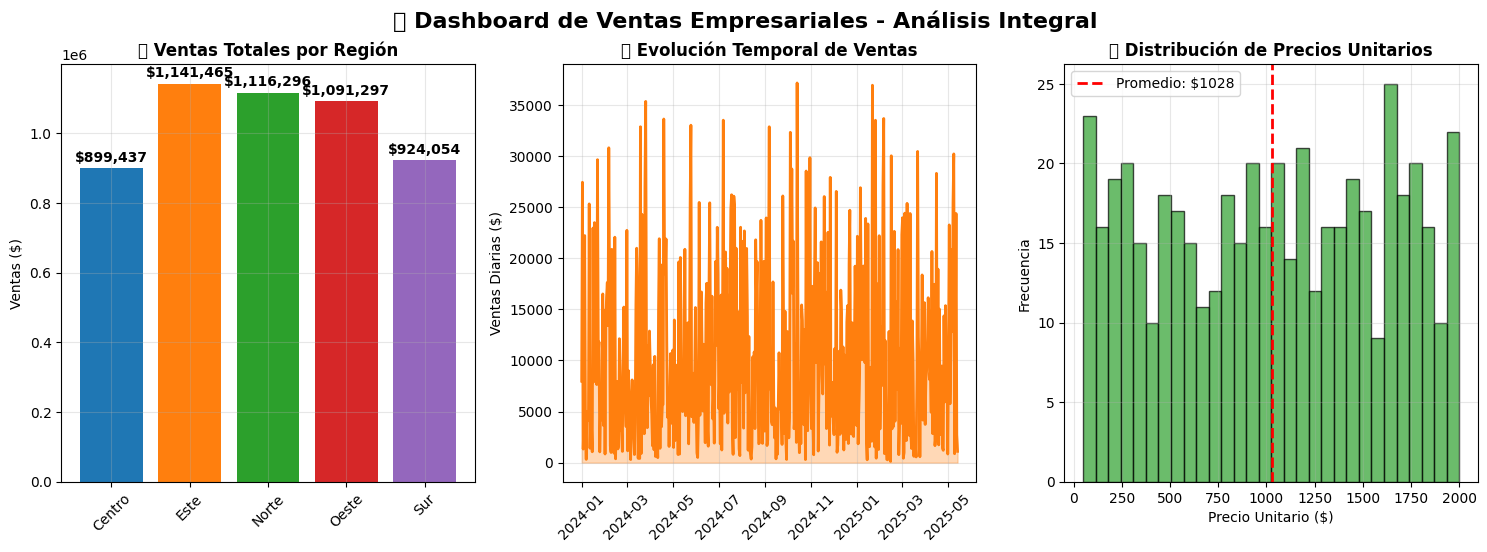

✅ Dashboard principal creado exitosamente


In [23]:
# ═══════════════════════════════════════════════════════════════
# EJEMPLOS PRÁCTICOS DE MATPLOTLIB AVANZADO
# ═══════════════════════════════════════════════════════════════

# Configurar estilo empresarial
plt.style.use('default')
colores_empresa = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("🎨 MATPLOTLIB AVANZADO - Dashboard Empresarial")
print("="*50)

# ────────────────────────────────────────────────────────────
# 1. DASHBOARD MULTIDIMENSIONAL
# ────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(15, 10))
fig.suptitle('📊 Dashboard de Ventas Empresariales - Análisis Integral', fontsize=16, fontweight='bold')

# Subplot 1: Ventas por región (gráfico de barras)
ax1 = plt.subplot(2, 3, 1)
ventas_por_region = df_ventas.groupby('region')['ventas_total'].sum()
bars = ax1.bar(ventas_por_region.index, ventas_por_region.values, color=colores_empresa)
ax1.set_title('💰 Ventas Totales por Región', fontweight='bold')
ax1.set_ylabel('Ventas ($)')
ax1.tick_params(axis='x', rotation=45)

# Añadir valores en las barras
for bar, valor in zip(bars, ventas_por_region.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + valor*0.01, 
             f'${valor:,.0f}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Evolución temporal de ventas
ax2 = plt.subplot(2, 3, 2)
ventas_diarias = df_ventas.groupby('fecha')['ventas_total'].sum()
ax2.plot(ventas_diarias.index, ventas_diarias.values, color=colores_empresa[1], linewidth=2)
ax2.fill_between(ventas_diarias.index, ventas_diarias.values, alpha=0.3, color=colores_empresa[1])
ax2.set_title('📈 Evolución Temporal de Ventas', fontweight='bold')
ax2.set_ylabel('Ventas Diarias ($)')
ax2.tick_params(axis='x', rotation=45)

# Subplot 3: Distribución de precios (histograma)
ax3 = plt.subplot(2, 3, 3)
ax3.hist(df_ventas['precio_unitario'], bins=30, color=colores_empresa[2], alpha=0.7, edgecolor='black')
ax3.axvline(df_ventas['precio_unitario'].mean(), color='red', linestyle='--', linewidth=2, label=f'Promedio: ${df_ventas["precio_unitario"].mean():.0f}')
ax3.set_title('📊 Distribución de Precios Unitarios', fontweight='bold')
ax3.set_xlabel('Precio Unitario ($)')
ax3.set_ylabel('Frecuencia')
ax3.legend()

plt.tight_layout()
plt.show()

print("✅ Dashboard principal creado exitosamente")

---

<a id="seaborn"></a>

## 6️⃣ Seaborn para Análisis Estadístico

### 📌 Conceptos Fundamentales

Seaborn está construido sobre matplotlib y está especializado en visualizaciones estadísticas. Es ideal para análisis exploratorio de datos y identificación de patrones en datos empresariales.

### 📐 Ventajas de Seaborn

| Característica | Beneficio | Uso Empresarial |
|----------------|-----------|----------------|
| **Estilo automático** | Gráficos más atractivos | Presentaciones profesionales |
| **Integración con pandas** | Trabaja directamente con DataFrames | Análisis directo de bases |
| **Funciones estadísticas** | Líneas de tendencia automáticas | Correlaciones y regresiones |
| **Paletas de colores** | Colores categóricos inteligentes | Diferenciación clara |

### 🔍 Tipos de Gráficos Principales

#### **1. Gráficos de Distribución**
- `histplot()`: Histogramas y densidades
- `boxplot()`: Análisis de outliers y cuartiles
- `violinplot()`: Combinación de boxplot + densidad

#### **2. Gráficos de Relación**
- `scatterplot()`: Correlaciones entre variables
- `lineplot()`: Series temporales y tendencias
- `regplot()`: Regresión lineal automática

#### **3. Gráficos Categóricos**
- `barplot()`: Promedios por categoría
- `countplot()`: Frecuencias categóricas
- `pointplot()`: Comparación de medias

#### **4. Matrices de Datos**
- `heatmap()`: Correlaciones y tablas pivot
- `clustermap()`: Agrupamiento jerárquico

📈 SEABORN - Análisis Estadístico Avanzado


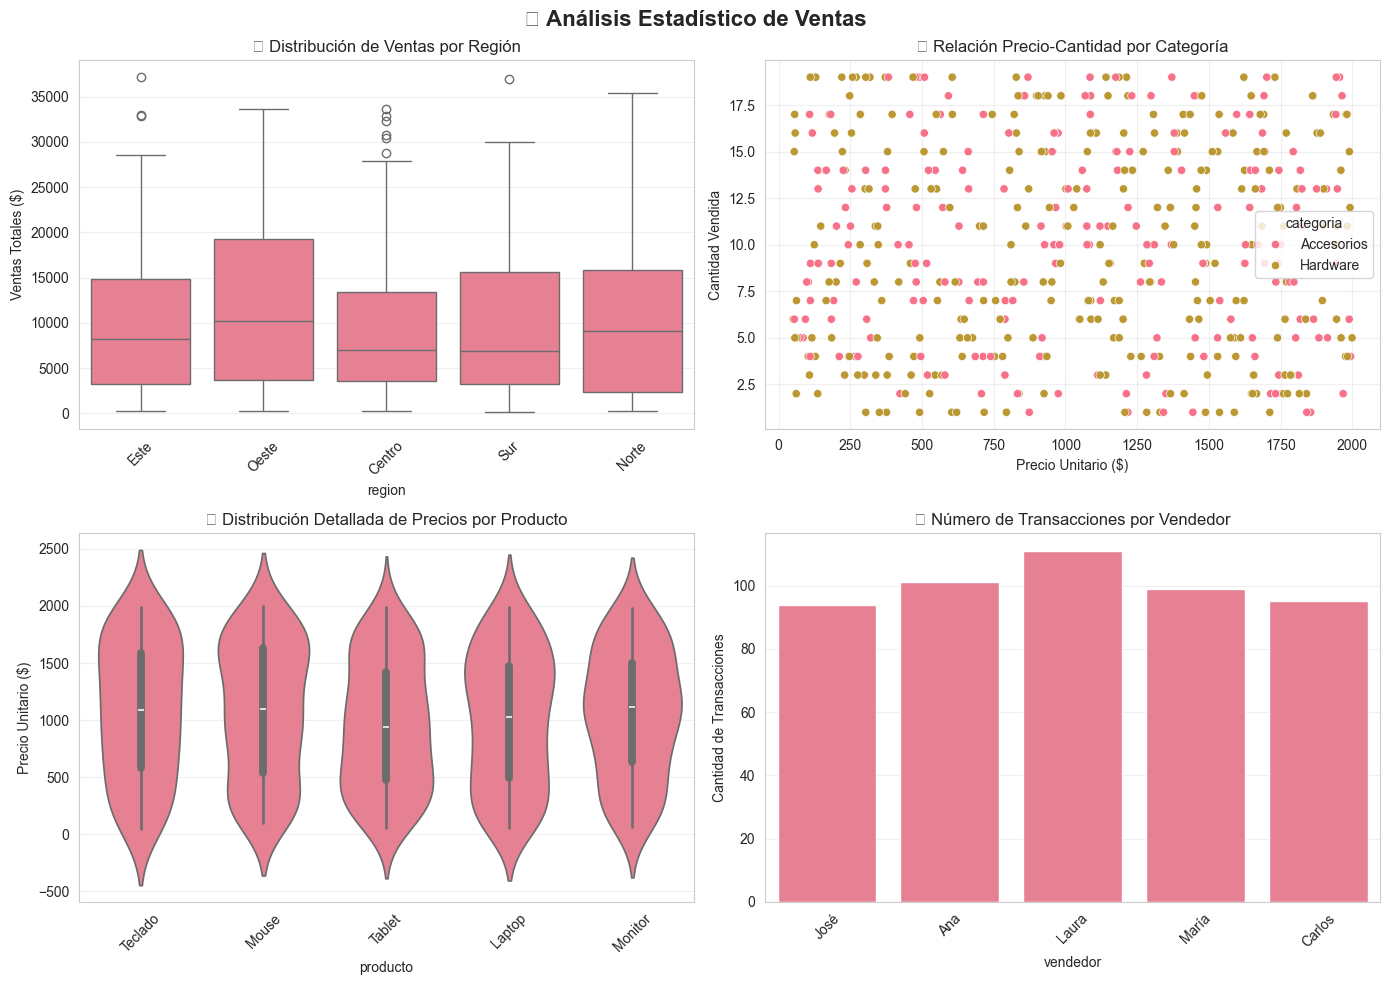

✅ Análisis estadístico completado


In [24]:
# ═══════════════════════════════════════════════════════════════
# EJEMPLOS PRÁCTICOS DE SEABORN PARA ANÁLISIS ESTADÍSTICO
# ═══════════════════════════════════════════════════════════════

print("📈 SEABORN - Análisis Estadístico Avanzado")
print("="*50)

# Configurar estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")

# ────────────────────────────────────────────────────────────
# 1. ANÁLISIS DE DISTRIBUCIONES POR CATEGORÍAS
# ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Análisis Estadístico de Ventas', fontsize=16, fontweight='bold')

# Subplot 1: Distribución de ventas por región
ax1 = axes[0, 0]
sns.boxplot(data=df_ventas, x='region', y='ventas_total', ax=ax1)
ax1.set_title('📦 Distribución de Ventas por Región')
ax1.set_ylabel('Ventas Totales ($)')
ax1.tick_params(axis='x', rotation=45)

# Subplot 2: Relación precio-cantidad con categorías
ax2 = axes[0, 1] 
sns.scatterplot(data=df_ventas, x='precio_unitario', y='cantidad', hue='categoria', ax=ax2)
ax2.set_title('🔗 Relación Precio-Cantidad por Categoría')
ax2.set_xlabel('Precio Unitario ($)')
ax2.set_ylabel('Cantidad Vendida')

# Subplot 3: Violin plot para análisis detallado de distribuciones
ax3 = axes[1, 0]
sns.violinplot(data=df_ventas, x='producto', y='precio_unitario', ax=ax3)
ax3.set_title('🎻 Distribución Detallada de Precios por Producto')
ax3.set_ylabel('Precio Unitario ($)')
ax3.tick_params(axis='x', rotation=45)

# Subplot 4: Conteo de transacciones por vendedor
ax4 = axes[1, 1]
sns.countplot(data=df_ventas, x='vendedor', ax=ax4)
ax4.set_title('👥 Número de Transacciones por Vendedor')
ax4.set_ylabel('Cantidad de Transacciones')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✅ Análisis estadístico completado")


🔥 MAPA DE CALOR - Matriz de Correlación
--------------------------------------------------


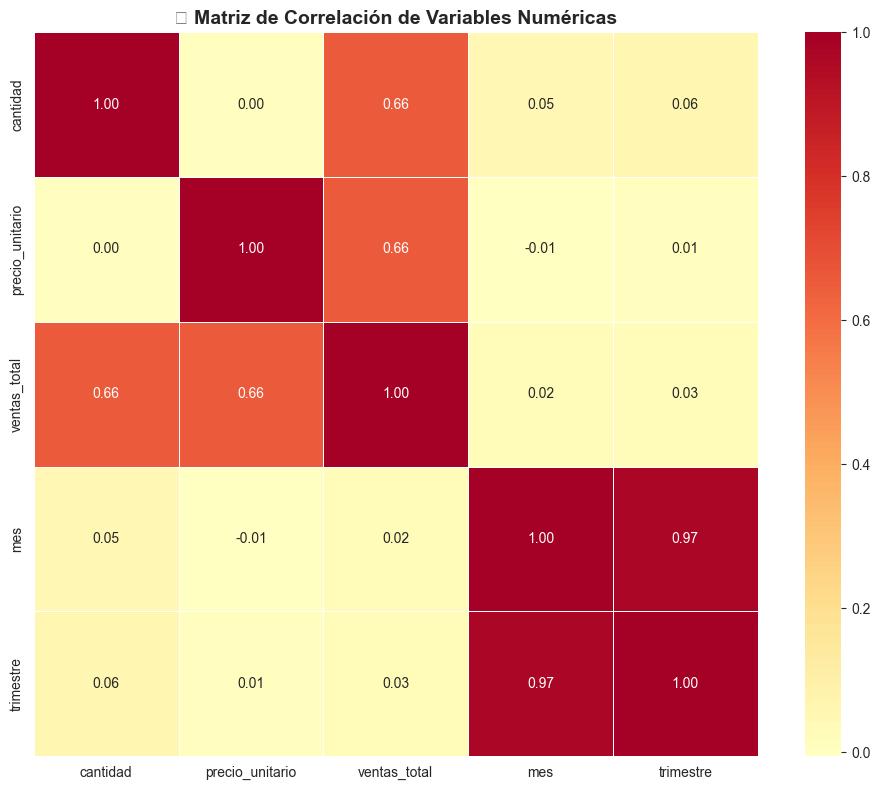


🔍 Correlaciones Importantes (|r| > 0.5):
   📈 cantidad ↔ ventas_total: 0.658 (positiva)
   📈 precio_unitario ↔ ventas_total: 0.660 (positiva)
   📈 mes ↔ trimestre: 0.972 (positiva)


In [25]:
# ────────────────────────────────────────────────────────────
# 2. MATRIZ DE CORRELACIÓN CON HEATMAP
# ────────────────────────────────────────────────────────────

print("\n🔥 MAPA DE CALOR - Matriz de Correlación")
print("-"*50)

# Preparar datos numéricos para correlación
datos_numericos = df_ventas[['cantidad', 'precio_unitario', 'ventas_total', 'mes', 'trimestre']].copy()

# Calcular matriz de correlación
matriz_correlacion = datos_numericos.corr()

# Crear heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, 
            annot=True,  # Mostrar valores
            cmap='RdYlBu_r',  # Paleta de colores
            center=0,  # Centrar en 0
            square=True,  # Celdas cuadradas
            linewidths=0.5,  # Líneas entre celdas
            fmt='.2f')  # Formato de números

plt.title('🔥 Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Análisis de correlaciones importantes
correlaciones_importantes = []
for i in range(len(matriz_correlacion.columns)):
    for j in range(i+1, len(matriz_correlacion.columns)):
        var1 = matriz_correlacion.columns[i]
        var2 = matriz_correlacion.columns[j]
        corr = matriz_correlacion.iloc[i, j]
        if abs(corr) > 0.5:  # Solo correlaciones fuertes
            correlaciones_importantes.append((var1, var2, corr))

print("\n🔍 Correlaciones Importantes (|r| > 0.5):")
for var1, var2, corr in correlaciones_importantes:
    direccion = "positiva" if corr > 0 else "negativa"
    print(f"   📈 {var1} ↔ {var2}: {corr:.3f} ({direccion})")

---

<a id="tendencia-central"></a>

## 9️⃣ Medidas de Tendencia Central

### 📌 Conceptos Fundamentales

Las medidas de tendencia central son el punto de partida de cualquier análisis estadístico empresarial. Nos indican el valor "típico" o representativo de un conjunto de datos.

### 📐 Las Tres Medidas Principales

| Medida | Fórmula | Interpretación Empresarial | Cuándo Usar |
|--------|---------|---------------------------|-------------|
| **Media** | $\bar{x} = \frac{\sum x_i}{n}$ | Valor promedio esperado | Datos sin outliers extremos |
| **Mediana** | Valor central ordenado | Valor típico real | Con outliers o distribuciones asimétricas |
| **Moda** | Valor más frecuente | Valor más común | Variables categóricas o identificar patrones |

### 🔍 Interpretación Empresarial

#### **Media Aritmética**
- **Ventaja**: Considera todos los valores
- **Desventaja**: Sensible a valores extremos
- **Uso**: KPIs financieros, promedios de rendimiento

#### **Mediana**
- **Ventaja**: No afectada por outliers
- **Desventaja**: No considera todos los valores
- **Uso**: Salarios, precios de mercado, análisis de riesgo

#### **Moda**
- **Ventaja**: Valor más representativo
- **Desventaja**: Puede no existir o no ser única
- **Uso**: Preferencias de clientes, productos más vendidos

### 💡 Funciones en Python

```python
# Con pandas
df['columna'].mean()    # Media
df['columna'].median()  # Mediana
df['columna'].mode()    # Moda

# Con numpy
np.mean(datos)
np.median(datos)
# Para moda, usar scipy.stats
from scipy import stats
stats.mode(datos)

# Estadísticas descriptivas completas
df.describe()
```

### ⚠️ Consideraciones Importantes

- **Distribución simétrica**: Media ≈ Mediana
- **Distribución asimétrica positiva**: Media > Mediana
- **Distribución asimétrica negativa**: Media < Mediana
- **Outliers**: Pueden distorsionar significativamente la media

In [26]:
# ═══════════════════════════════════════════════════════════════
# ANÁLISIS ESTADÍSTICO DESCRIPTIVO COMPLETO
# ═══════════════════════════════════════════════════════════════

print("📊 ANÁLISIS ESTADÍSTICO DESCRIPTIVO")
print("="*50)

# ────────────────────────────────────────────────────────────
# 1. MEDIDAS DE TENDENCIA CENTRAL
# ────────────────────────────────────────────────────────────

print("\n1️⃣ MEDIDAS DE TENDENCIA CENTRAL")
print("-"*50)

# Análisis de ventas totales
ventas_stats = {
    'Media': df_ventas['ventas_total'].mean(),
    'Mediana': df_ventas['ventas_total'].median(),
    'Moda': df_ventas['ventas_total'].mode().iloc[0] if not df_ventas['ventas_total'].mode().empty else 'No hay moda única'
}

print("💰 Análisis de Ventas Totales:")
for medida, valor in ventas_stats.items():
    if isinstance(valor, (int, float)):
        print(f"   {medida:12}: ${valor:,.2f}")
    else:
        print(f"   {medida:12}: {valor}")

# Interpretación de asimetría
media_ventas = ventas_stats['Media']
mediana_ventas = ventas_stats['Mediana']

if media_ventas > mediana_ventas:
    asimetria = "positiva (cola derecha)"
    interpretacion = "Hay valores altos que elevan la media"
elif media_ventas < mediana_ventas:
    asimetria = "negativa (cola izquierda)"
    interpretacion = "Hay valores bajos que reducen la media"
else:
    asimetria = "simétrica"
    interpretacion = "La distribución es equilibrada"

print(f"\n📈 Interpretación:")
print(f"   Distribución: {asimetria}")
print(f"   Explicación: {interpretacion}")

# ────────────────────────────────────────────────────────────
# 2. ANÁLISIS POR CATEGORÍAS
# ────────────────────────────────────────────────────────────

print(f"\n2️⃣ TENDENCIA CENTRAL POR CATEGORÍAS")
print("-"*50)

# Por región
print("🏢 Por Región:")
tendencia_region = df_ventas.groupby('region')['ventas_total'].agg(['mean', 'median']).round(2)
tendencia_region.columns = ['Media ($)', 'Mediana ($)']
print(tendencia_region)

# Por producto
print("\n📦 Por Producto:")
tendencia_producto = df_ventas.groupby('producto')['precio_unitario'].agg(['mean', 'median']).round(2)
tendencia_producto.columns = ['Precio_Medio ($)', 'Precio_Mediano ($)']
print(tendencia_producto.sort_values('Precio_Medio ($)', ascending=False))

📊 ANÁLISIS ESTADÍSTICO DESCRIPTIVO

1️⃣ MEDIDAS DE TENDENCIA CENTRAL
--------------------------------------------------
💰 Análisis de Ventas Totales:
   Media       : $10,345.10
   Mediana     : $7,938.20
   Moda        : $122.10

📈 Interpretación:
   Distribución: positiva (cola derecha)
   Explicación: Hay valores altos que elevan la media

2️⃣ TENDENCIA CENTRAL POR CATEGORÍAS
--------------------------------------------------
🏢 Por Región:
        Media ($)  Mediana ($)
region                        
Centro    9883.92      7056.79
Este     10191.65      8182.45
Norte    10241.25      9074.02
Oeste    11734.37     10220.98
Sur       9726.89      6909.11

📦 Por Producto:
          Precio_Medio ($)  Precio_Mediano ($)
producto                                      
Mouse              1070.33             1097.16
Teclado            1067.24             1086.34
Monitor            1051.68             1112.41
Laptop             1000.66             1025.06
Tablet              957.00           

---

<a id="dispersion"></a>

## 🔟 Dispersión y Variabilidad

### 📌 Conceptos Fundamentales

Las medidas de dispersión indican qué tan separados están los datos del valor central. En análisis empresarial, la variabilidad es crucial para evaluar riesgo, consistencia y predictibilidad.

### 📐 Medidas Principales de Dispersión

| Medida | Fórmula | Interpretación | Uso Empresarial |
|--------|---------|----------------|----------------|
| **Rango** | Max - Min | Amplitud total | Análisis rápido de volatilidad |
| **Varianza** | $\sigma^2 = \frac{\sum(x_i - \bar{x})^2}{n}$ | Dispersión promedio al cuadrado | Base para otros cálculos |
| **Desviación Estándar** | $\sigma = \sqrt{\sigma^2}$ | Dispersión en unidades originales | Riesgo, control de calidad |
| **Coeficiente de Variación** | $CV = \frac{\sigma}{\bar{x}} \times 100$ | Variabilidad relativa (%) | Comparar diferentes escalas |

### 🔍 Medidas de Posición

#### **Cuartiles y Percentiles**

```python
Q1 = df['columna'].quantile(0.25)    # Primer cuartil
Q2 = df['columna'].quantile(0.50)    # Segundo cuartil (mediana)  
Q3 = df['columna'].quantile(0.75)    # Tercer cuartil
IQR = Q3 - Q1                        # Rango intercuartílico
```

#### **Regla para Detectar Outliers**

```python
# Límites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df[(df['columna'] < limite_inferior) | 
              (df['columna'] > limite_superior)]
```

### 💼 Interpretación Empresarial

#### **Baja Variabilidad** 
- **Ventaja**: Predictibilidad, consistencia
- **Uso**: Procesos controlados, planificación confiable
- **Ejemplo**: Costos fijos, productos estándar

#### **Alta Variabilidad**
- **Interpretación**: Mayor riesgo, menor predictibilidad
- **Uso**: Análisis de volatilidad, gestión de riesgo
- **Ejemplo**: Precios de commodities, demanda estacional

### ⚠️ Consideraciones Importantes

- **Escala**: La desviación estándar depende de la escala de los datos
- **Distribución**: Funciona mejor con distribuciones normales
- **Coeficiente de Variación**: Permite comparar variabilidades entre diferentes variables
- **Outliers**: Pueden inflar artificialmente las medidas de dispersión

In [27]:
# ────────────────────────────────────────────────────────────
# 3. MEDIDAS DE DISPERSIÓN Y VARIABILIDAD
# ────────────────────────────────────────────────────────────

print("\n3️⃣ ANÁLISIS DE DISPERSIÓN Y VARIABILIDAD")
print("-"*50)

# Calcular todas las medidas de dispersión para ventas totales
print("💰 Análisis de Dispersión - Ventas Totales:")

rango = df_ventas['ventas_total'].max() - df_ventas['ventas_total'].min()
varianza = df_ventas['ventas_total'].var()
desv_estandar = df_ventas['ventas_total'].std()
cv = (desv_estandar / df_ventas['ventas_total'].mean()) * 100

print(f"   Rango              : ${rango:,.2f}")
print(f"   Varianza           : ${varianza:,.2f}")
print(f"   Desviación Estándar: ${desv_estandar:,.2f}")
print(f"   Coef. de Variación : {cv:.2f}%")

# Análisis de cuartiles
Q1 = df_ventas['ventas_total'].quantile(0.25)
Q2 = df_ventas['ventas_total'].quantile(0.50)  # Mediana
Q3 = df_ventas['ventas_total'].quantile(0.75)
IQR = Q3 - Q1

print(f"\n📊 Análisis de Cuartiles:")
print(f"   Q1 (25%)           : ${Q1:,.2f}")
print(f"   Q2 (50% - Mediana) : ${Q2:,.2f}")
print(f"   Q3 (75%)           : ${Q3:,.2f}")
print(f"   IQR (Q3 - Q1)      : ${IQR:,.2f}")

# ────────────────────────────────────────────────────────────
# 4. DETECCIÓN DE OUTLIERS
# ────────────────────────────────────────────────────────────

print(f"\n4️⃣ DETECCIÓN DE OUTLIERS")
print("-"*50)

# Calcular límites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df_ventas[(df_ventas['ventas_total'] < limite_inferior) | 
                    (df_ventas['ventas_total'] > limite_superior)]

print(f"📈 Límites para outliers:")
print(f"   Límite inferior    : ${limite_inferior:,.2f}")
print(f"   Límite superior    : ${limite_superior:,.2f}")
print(f"   Número de outliers : {len(outliers)}")
print(f"   Porcentaje outliers: {len(outliers)/len(df_ventas)*100:.2f}%")

if len(outliers) > 0:
    print(f"\n🚨 Outliers encontrados:")
    print(f"   Venta mínima atípica: ${outliers['ventas_total'].min():,.2f}")
    print(f"   Venta máxima atípica: ${outliers['ventas_total'].max():,.2f}")

# ────────────────────────────────────────────────────────────
# 5. COMPARACIÓN DE VARIABILIDAD ENTRE REGIONES
# ────────────────────────────────────────────────────────────

print(f"\n5️⃣ COMPARACIÓN DE VARIABILIDAD POR REGIÓN")
print("-"*50)

# Calcular coeficiente de variación por región
cv_regiones = []
for region in df_ventas['region'].unique():
    datos_region = df_ventas[df_ventas['region'] == region]['ventas_total']
    cv_region = (datos_region.std() / datos_region.mean()) * 100
    cv_regiones.append({'Region': region, 'CV': cv_region, 'Interpretacion': ''})

# Crear DataFrame con resultados
df_cv = pd.DataFrame(cv_regiones)
df_cv = df_cv.sort_values('CV')

# Añadir interpretación
for i, row in df_cv.iterrows():
    if row['CV'] < 30:
        df_cv.at[i, 'Interpretacion'] = 'Baja variabilidad'
    elif row['CV'] < 60:
        df_cv.at[i, 'Interpretacion'] = 'Variabilidad moderada'
    else:
        df_cv.at[i, 'Interpretacion'] = 'Alta variabilidad'

print("🏢 Coeficiente de Variación por Región:")
for _, row in df_cv.iterrows():
    print(f"   {row['Region']:8}: {row['CV']:6.2f}% - {row['Interpretacion']}")

print(f"\n🎯 Región más consistente: {df_cv.iloc[0]['Region']} (CV = {df_cv.iloc[0]['CV']:.2f}%)")
print(f"🎲 Región más variable: {df_cv.iloc[-1]['Region']} (CV = {df_cv.iloc[-1]['CV']:.2f}%)")


3️⃣ ANÁLISIS DE DISPERSIÓN Y VARIABILIDAD
--------------------------------------------------
💰 Análisis de Dispersión - Ventas Totales:
   Rango              : $37,042.47
   Varianza           : $74,000,771.05
   Desviación Estándar: $8,602.37
   Coef. de Variación : 83.15%

📊 Análisis de Cuartiles:
   Q1 (25%)           : $3,303.44
   Q2 (50% - Mediana) : $7,938.20
   Q3 (75%)           : $15,764.81
   IQR (Q3 - Q1)      : $12,461.37

4️⃣ DETECCIÓN DE OUTLIERS
--------------------------------------------------
📈 Límites para outliers:
   Límite inferior    : $-15,388.61
   Límite superior    : $34,456.86
   Número de outliers : 3
   Porcentaje outliers: 0.60%

🚨 Outliers encontrados:
   Venta mínima atípica: $35,361.18
   Venta máxima atípica: $37,164.57

5️⃣ COMPARACIÓN DE VARIABILIDAD POR REGIÓN
--------------------------------------------------
🏢 Coeficiente de Variación por Región:
   Oeste   :  76.43% - Alta variabilidad
   Este    :  82.95% - Alta variabilidad
   Norte   :  84.

---

<a id="caso-practico"></a>

## 1️⃣4️⃣ Caso Práctico Completo

### 📌 Situación Empresarial

**Empresa**: TechnoStore SA - Cadena de tiendas de tecnología  
**Objetivo**: Análisis integral de ventas para optimizar estrategia comercial  
**Datos**: 500 transacciones de ventas del primer semestre 2024  

### 🎯 Objetivos del Análisis

1. **📊 Análisis Descriptivo**: Caracterizar el comportamiento de ventas
2. **🏢 Análisis por Segmentos**: Identificar patrones por región, producto y vendedor  
3. **📈 Análisis Temporal**: Evaluar tendencias y estacionalidad
4. **💰 Análisis de Rentabilidad**: Optimizar mix de productos
5. **🎯 Recomendaciones**: Estrategias basadas en datos

### 🔍 Metodología de Análisis

```
FASE 1: Exploración Inicial
├── Limpieza y validación de datos
├── Estadísticas descriptivas básicas
└── Identificación de outliers

FASE 2: Análisis Multidimensional  
├── Segmentación por categorías
├── Análisis de correlaciones
└── Detección de patrones

FASE 3: Visualización Estratégica
├── Dashboard ejecutivo
├── Gráficos de tendencias
└── Mapas de calor

FASE 4: Insights y Recomendaciones
├── Síntesis de hallazgos
├── Implicaciones de negocio
└── Estrategias recomendadas
```

### 📊 Técnicas Aplicadas

- **Agrupación (groupby)**: Análisis por dimensiones
- **Pivoteo**: Matrices de performance 
- **Merge**: Enriquecimiento de datos
- **Visualización**: Matplotlib + Seaborn
- **Estadística descriptiva**: Tendencia y dispersión
- **Correlación**: Relaciones entre variables

In [28]:
# ═══════════════════════════════════════════════════════════════
# CASO PRÁCTICO COMPLETO: ANÁLISIS INTEGRAL DE TECHNOSTORE SA
# ═══════════════════════════════════════════════════════════════

print("🏢 CASO PRÁCTICO: TECHNOSTORE SA")
print("="*60)
print("📋 Análisis Integral de Ventas - Primer Semestre 2024")
print("="*60)

# ────────────────────────────────────────────────────────────
# FASE 1: EXPLORACIÓN INICIAL Y VALIDACIÓN
# ────────────────────────────────────────────────────────────

print("\n🔍 FASE 1: EXPLORACIÓN INICIAL")
print("-"*40)

# Resumen ejecutivo de datos
print("📊 RESUMEN EJECUTIVO:")
print(f"   • Total de transacciones: {len(df_ventas):,}")
print(f"   • Período analizado: {df_ventas['fecha'].min().strftime('%d/%m/%Y')} - {df_ventas['fecha'].max().strftime('%d/%m/%Y')}")
print(f"   • Regiones cubiertas: {df_ventas['region'].nunique()}")
print(f"   • Productos ofrecidos: {df_ventas['producto'].nunique()}")
print(f"   • Vendedores activos: {df_ventas['vendedor'].nunique()}")
print(f"   • Facturación total: ${df_ventas['ventas_total'].sum():,.2f}")

# Estadísticas por dimensión clave
print(f"\n💰 MÉTRICAS CLAVE:")
print(f"   • Venta promedio: ${df_ventas['ventas_total'].mean():,.2f}")
print(f"   • Ticket mínimo: ${df_ventas['ventas_total'].min():,.2f}")
print(f"   • Ticket máximo: ${df_ventas['ventas_total'].max():,.2f}")
print(f"   • Desviación estándar: ${df_ventas['ventas_total'].std():,.2f}")

# ────────────────────────────────────────────────────────────
# FASE 2: ANÁLISIS POR SEGMENTOS ESTRATÉGICOS
# ────────────────────────────────────────────────────────────

print(f"\n🎯 FASE 2: ANÁLISIS POR SEGMENTOS")
print("-"*40)

# Top performers por diferentes dimensiones
print("🏆 TOP PERFORMERS:")

# Por región
top_region = df_ventas.groupby('region')['ventas_total'].sum().sort_values(ascending=False)
print(f"   🌍 Región líder: {top_region.index[0]} (${top_region.iloc[0]:,.2f})")

# Por producto  
top_producto = df_ventas.groupby('producto')['ventas_total'].sum().sort_values(ascending=False)
print(f"   📦 Producto estrella: {top_producto.index[0]} (${top_producto.iloc[0]:,.2f})")

# Por vendedor
top_vendedor = df_ventas.groupby('vendedor')['ventas_total'].sum().sort_values(ascending=False)
print(f"   👥 Vendedor top: {top_vendedor.index[0]} (${top_vendedor.iloc[0]:,.2f})")

# Análisis de concentración
concentracion_region = (top_region.iloc[0] / top_region.sum() * 100)
print(f"   📈 Concentración regional: {concentracion_region:.1f}% en región líder")

# ────────────────────────────────────────────────────────────
# FASE 3: ANÁLISIS DE RENTABILIDAD CON MERGE
# ────────────────────────────────────────────────────────────

print(f"\n💼 FASE 3: ANÁLISIS DE RENTABILIDAD")
print("-"*40)

# Merge con datos de productos para calcular rentabilidad
ventas_rentabilidad = pd.merge(df_ventas, df_productos, on='producto', how='inner')
ventas_rentabilidad['margen_unitario'] = ventas_rentabilidad['precio_unitario'] - ventas_rentabilidad['costo_unitario']
ventas_rentabilidad['margen_total'] = ventas_rentabilidad['margen_unitario'] * ventas_rentabilidad['cantidad']

# Análisis de rentabilidad por producto
rentabilidad_resumen = ventas_rentabilidad.groupby('producto').agg({
    'ventas_total': 'sum',
    'margen_total': 'sum',
    'cantidad': 'sum'
}).round(2)

rentabilidad_resumen['margen_porcentual'] = (rentabilidad_resumen['margen_total'] / 
                                           rentabilidad_resumen['ventas_total'] * 100).round(1)

print("💰 ANÁLISIS DE RENTABILIDAD POR PRODUCTO:")
rentabilidad_ordenado = rentabilidad_resumen.sort_values('margen_total', ascending=False)
for producto, datos in rentabilidad_ordenado.iterrows():
    print(f"   📦 {producto:8}: Margen ${datos['margen_total']:>8,.0f} ({datos['margen_porcentual']:>5.1f}%)")

# Identificar productos problemáticos
productos_baja_rentabilidad = rentabilidad_resumen[rentabilidad_resumen['margen_porcentual'] < 20]
if len(productos_baja_rentabilidad) > 0:
    print(f"\n⚠️ PRODUCTOS CON BAJA RENTABILIDAD (<20%):")
    for producto in productos_baja_rentabilidad.index:
        margen = productos_baja_rentabilidad.loc[producto, 'margen_porcentual']
        print(f"   🔴 {producto}: {margen:.1f}%")

🏢 CASO PRÁCTICO: TECHNOSTORE SA
📋 Análisis Integral de Ventas - Primer Semestre 2024

🔍 FASE 1: EXPLORACIÓN INICIAL
----------------------------------------
📊 RESUMEN EJECUTIVO:
   • Total de transacciones: 500
   • Período analizado: 01/01/2024 - 14/05/2025
   • Regiones cubiertas: 5
   • Productos ofrecidos: 5
   • Vendedores activos: 5
   • Facturación total: $5,172,549.06

💰 MÉTRICAS CLAVE:
   • Venta promedio: $10,345.10
   • Ticket mínimo: $122.10
   • Ticket máximo: $37,164.57
   • Desviación estándar: $8,602.37

🎯 FASE 2: ANÁLISIS POR SEGMENTOS
----------------------------------------
🏆 TOP PERFORMERS:
   🌍 Región líder: Este ($1,141,464.68)
   📦 Producto estrella: Mouse ($1,151,515.58)
   👥 Vendedor top: Laura ($1,102,674.88)
   📈 Concentración regional: 22.1% en región líder

💼 FASE 3: ANÁLISIS DE RENTABILIDAD
----------------------------------------
💰 ANÁLISIS DE RENTABILIDAD POR PRODUCTO:
   📦 Mouse   : Margen $1,124,716 ( 97.7%)
   📦 Monitor : Margen $ 856,513 ( 77.3%)
   

In [29]:
# ────────────────────────────────────────────────────────────
# FASE 4: INSIGHTS Y RECOMENDACIONES ESTRATÉGICAS
# ────────────────────────────────────────────────────────────

print(f"\n🚀 FASE 4: INSIGHTS Y RECOMENDACIONES")
print("-"*40)

# Calcular métricas clave para recomendaciones
total_ventas = df_ventas['ventas_total'].sum()
total_margen = ventas_rentabilidad['margen_total'].sum()
margen_global = (total_margen / total_ventas * 100)

# Análisis de desempeño por vendedor con merge
ventas_vendedores = pd.merge(df_ventas.groupby('vendedor')['ventas_total'].sum().reset_index(), 
                           df_vendedores, on='vendedor', how='inner')
ventas_vendedores['comision_ganada'] = ventas_vendedores['ventas_total'] * ventas_vendedores['comision_pct']

print("🎯 INSIGHTS CLAVE:")
print(f"   💰 Margen global: {margen_global:.1f}%")
print(f"   🏆 Mejor región: {top_region.index[0]} ({concentracion_region:.1f}% de las ventas)")
print(f"   📦 Producto estrella: {top_producto.index[0]}")
print(f"   👥 Vendedor top: {top_vendedor.index[0]}")

# Variabilidad por región (riesgo/consistencia)
cv_por_region = df_ventas.groupby('region')['ventas_total'].agg(['std', 'mean'])
cv_por_region['cv'] = (cv_por_region['std'] / cv_por_region['mean'] * 100)
region_mas_estable = cv_por_region['cv'].idxmin()
region_mas_volatil = cv_por_region['cv'].idxmax()

print(f"   📈 Región más consistente: {region_mas_estable}")
print(f"   📊 Región más volátil: {region_mas_volatil}")

print(f"\n💡 RECOMENDACIONES ESTRATÉGICAS:")
print(f"   1️⃣ EXPANSIÓN: Replicar modelo de {top_region.index[0]} en otras regiones")
print(f"   2️⃣ PRODUCTOS: Incrementar promoción de {top_producto.index[0]}")
print(f"   3️⃣ VENDEDORES: Capacitar equipo con mejores prácticas de {top_vendedor.index[0]}")

# Recomendaciones específicas basadas en rentabilidad
if len(productos_baja_rentabilidad) > 0:
    print(f"   4️⃣ RENTABILIDAD: Revisar pricing de productos con margen <20%")
else:
    print(f"   4️⃣ RENTABILIDAD: Mantener mix actual, todos los productos son rentables")

print(f"   5️⃣ RIESGO: Diversificar operaciones en {region_mas_volatil} para reducir variabilidad")

print(f"\n📋 PRÓXIMOS PASOS:")
print(f"   • Implementar seguimiento semanal de métricas clave")
print(f"   • Desarrollar dashboard automatizado")
print(f"   • Establecer metas por región y vendedor")
print(f"   • Revisar estrategia de pricing mensualmente")

print(f"\n" + "="*60)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*60)


🚀 FASE 4: INSIGHTS Y RECOMENDACIONES
----------------------------------------
🎯 INSIGHTS CLAVE:
   💰 Margen global: 70.9%
   🏆 Mejor región: Este (22.1% de las ventas)
   📦 Producto estrella: Mouse
   👥 Vendedor top: Laura
   📈 Región más consistente: Oeste
   📊 Región más volátil: Sur

💡 RECOMENDACIONES ESTRATÉGICAS:
   1️⃣ EXPANSIÓN: Replicar modelo de Este en otras regiones
   2️⃣ PRODUCTOS: Incrementar promoción de Mouse
   3️⃣ VENDEDORES: Capacitar equipo con mejores prácticas de Laura
   4️⃣ RENTABILIDAD: Revisar pricing de productos con margen <20%
   5️⃣ RIESGO: Diversificar operaciones en Sur para reducir variabilidad

📋 PRÓXIMOS PASOS:
   • Implementar seguimiento semanal de métricas clave
   • Desarrollar dashboard automatizado
   • Establecer metas por región y vendedor
   • Revisar estrategia de pricing mensualmente

✅ ANÁLISIS COMPLETO FINALIZADO


---

<a id="funciones"></a>

## 1️⃣5️⃣ Tabla de Funciones de Referencia

### 📌 Funciones Esenciales para el Segundo Parcial

#### 🔗 **Operaciones de Agrupación (groupby)**

| Función | Sintaxis | Descripción | Ejemplo |
|---------|----------|-------------|---------|
| `groupby()` | `df.groupby('columna')` | Agrupa datos por categoría | `df.groupby('region')['ventas'].sum()` |
| `agg()` | `.agg(['sum', 'mean'])` | Múltiples agregaciones | `df.groupby('prod').agg({'ventas': ['sum', 'mean']})` |
| `size()` | `.size()` | Cuenta grupos (incluye NaN) | `df.groupby('categoria').size()` |
| `count()` | `.count()` | Cuenta valores no nulos | `df.groupby('categoria').count()` |
| `transform()` | `.transform('mean')` | Mantiene forma original | `df.groupby('region')['ventas'].transform('mean')` |

#### 🔄 **Pivoteo y Reshape**

| Función | Sintaxis | Descripción | Ejemplo |
|---------|----------|-------------|---------|
| `pivot()` | `df.pivot(index='fila', columns='col', values='val')` | Reestructura datos únicos | `df.pivot('fecha', 'producto', 'ventas')` |
| `pivot_table()` | `pd.pivot_table(df, values='val', index='fila')` | Agrega datos duplicados | `pd.pivot_table(df, values='ventas', index='region', aggfunc='mean')` |
| `melt()` | `pd.melt(df, id_vars=['col_fija'], value_vars=['col1'])` | De ancho a largo | `pd.melt(df, id_vars=['region'], value_vars=['ene', 'feb'])` |
| `unstack()` | `df.unstack()` | Series a DataFrame | `df.groupby(['region', 'mes']).sum().unstack()` |

#### 🔗 **Merge y Joins**

| Función | Sintaxis | Descripción | Ejemplo |
|---------|----------|-------------|---------|
| `merge()` | `pd.merge(df1, df2, on='clave', how='inner')` | Une DataFrames | `pd.merge(ventas, productos, on='producto_id')` |
| `join()` | `df1.join(df2, how='left')` | Une por índice | `df_ventas.join(df_regiones)` |
| `concat()` | `pd.concat([df1, df2], axis=0)` | Concatena DataFrames | `pd.concat([ventas_q1, ventas_q2])` |

#### 📊 **Visualización con Matplotlib**

| Función | Sintaxis | Descripción | Ejemplo |
|---------|----------|-------------|---------|
| `figure()` | `plt.figure(figsize=(8, 5))` | Crea figura | `plt.figure(figsize=(10, 6))` |
| `subplot()` | `plt.subplot(2, 2, 1)` | Múltiples gráficos | `plt.subplot(1, 2, 1)` |
| `plot()` | `plt.plot(x, y)` | Gráfico de líneas | `plt.plot(fechas, ventas)` |
| `bar()` | `plt.bar(categorias, valores)` | Gráfico de barras | `plt.bar(regiones, totales)` |
| `hist()` | `plt.hist(datos, bins=30)` | Histograma | `plt.hist(precios, bins=20)` |
| `scatter()` | `plt.scatter(x, y)` | Gráfico de dispersión | `plt.scatter(precio, cantidad)` |

#### 🎨 **Visualización con Seaborn**

| Función | Sintaxis | Descripción | Ejemplo |
|---------|----------|-------------|---------|
| `boxplot()` | `sns.boxplot(data=df, x='cat', y='num')` | Gráfico de cajas | `sns.boxplot(data=df, x='region', y='ventas')` |
| `heatmap()` | `sns.heatmap(matriz, annot=True)` | Mapa de calor | `sns.heatmap(correlaciones, annot=True)` |
| `scatterplot()` | `sns.scatterplot(data=df, x='x', y='y', hue='cat')` | Dispersión por categoría | `sns.scatterplot(data=df, x='precio', y='cantidad', hue='region')` |
| `lineplot()` | `sns.lineplot(data=df, x='fecha', y='ventas')` | Líneas con confianza | `sns.lineplot(data=df, x='mes', y='ventas')` |
| `countplot()` | `sns.countplot(data=df, x='categoria')` | Conteo categórico | `sns.countplot(data=df, x='producto')` |

#### 📈 **Estadística Descriptiva**

| Función | Sintaxis | Descripción | Ejemplo |
|---------|----------|-------------|---------|
| `describe()` | `df.describe()` | Resumen estadístico | `df['ventas'].describe()` |
| `mean()` | `df['col'].mean()` | Media aritmética | `df['ventas'].mean()` |
| `median()` | `df['col'].median()` | Mediana | `df['precios'].median()` |
| `std()` | `df['col'].std()` | Desviación estándar | `df['ventas'].std()` |
| `quantile()` | `df['col'].quantile(0.75)` | Percentiles | `df['ventas'].quantile([0.25, 0.75])` |
| `corr()` | `df.corr()` | Matriz de correlación | `df[['precio', 'cantidad', 'ventas']].corr()` |

#### 🔍 **Filtrado y Selección**

| Función | Sintaxis | Descripción | Ejemplo |
|---------|----------|-------------|---------|
| `query()` | `df.query('ventas > 1000')` | Filtro con expresión | `df.query('region == "Norte" and ventas > 500')` |
| `isin()` | `df['col'].isin(['val1', 'val2'])` | Filtro por lista | `df[df['producto'].isin(['Laptop', 'Tablet'])]` |
| `nlargest()` | `df.nlargest(5, 'ventas')` | Top N valores | `df.nlargest(10, 'ventas')` |
| `nsmallest()` | `df.nsmallest(5, 'ventas')` | Bottom N valores | `df.nsmallest(5, 'precios')` |

### 💡 **Patrones de Código Frecuentes**

```python
# Patrón 1: Análisis por grupos
resultado = df.groupby('categoria').agg({
    'ventas': ['sum', 'mean'],
    'cantidad': 'count'
})

# Patrón 2: Pivot con visualización
tabla = pd.pivot_table(df, values='ventas', index='region', columns='mes', aggfunc='sum')
sns.heatmap(tabla, annot=True)

# Patrón 3: Merge y análisis
df_completo = pd.merge(ventas, productos, on='producto_id')
df_completo['margen'] = df_completo['precio'] - df_completo['costo']

# Patrón 4: Dashboard básico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df.groupby('categoria')['ventas'].sum().plot(kind='bar', ax=axes[0,0])
```

---

### ⭐ **Recordatorios Importantes para Examen**

1. **🔍 Siempre explorar datos**: `df.info()`, `df.describe()`, `df.head()`
2. **🎨 Configurar visualizaciones**: `plt.figure(figsize=(8,5))`, títulos y etiquetas
3. **📊 Interpretar resultados**: No solo calcular, explicar qué significa
4. **🔗 Combinar técnicas**: groupby → pivot → visualización → conclusiones
5. **⚠️ Manejar valores faltantes**: `df.isnull().sum()`, estrategias de limpieza

---

**🎯 Esta guía cubre todos los temas fundamentales para el segundo parcial de TGAD-FCE**